# Mesure et backtesting du risque de marché d’un portefeuille

Ce notebook présente une analyse du risque de marché appliquée à un portefeuille diversifié d’ETF.  
L’objectif est de comparer plusieurs mesures de risque :
- VaR historique
- VaR paramétrique
- Expected Shortfall

Le projet inclut également un backtesting sur fenêtre glissante afin d’évaluer la robustesse des estimations de VaR.

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from src.data_loader import load_prices, compute_returns
from src.portfolio import portfolio_returns
from src.risk_metrics import historical_var, parametric_var, expected_shortfall
from src.backtesting import rolling_var_backtest, exception_rate

## 1. Données et construction du portefeuille

Le portefeuille étudié est composé de quatre ETF représentatifs de différentes classes d’actifs :
- SPY : actions américaines larges capitalisations
- QQQ : actions technologiques américaines
- TLT : obligations souveraines américaines longues
- GLD : or

Les poids retenus sont :
- 40 % SPY
- 30 % QQQ
- 20 % TLT
- 10 % GLD

In [5]:
tickers = ["SPY", "QQQ", "TLT", "GLD"]
weights = [0.4, 0.3, 0.2, 0.1]

prices = load_prices(tickers, start="2020-01-01")
returns = compute_returns(prices)
port_returns = portfolio_returns(returns, weights)

prices.tail()

Ticker,GLD,QQQ,SPY,TLT
Date,,,,
2026-03-24,404.130005,583.979980,653.179993,86.010002
2026-03-25,416.290009,587.820007,656.820007,86.839996
2026-03-26,400.640015,573.789978,645.090027,86.110001
2026-03-27,414.700012,562.580017,634.090027,85.639999
2026-03-30,414.909393,558.729980,632.340027,86.750000


In [6]:
var_hist_95 = historical_var(port_returns, alpha=0.95)
var_para_95 = parametric_var(port_returns, alpha=0.95)
es_95 = expected_shortfall(port_returns, alpha=0.95)

print("VaR historique 95% :", round(var_hist_95, 4))
print("VaR paramétrique 95% :", round(var_para_95, 4))
print("Expected Shortfall 95% :", round(es_95, 4))

VaR historique 95% : 0.0142
VaR paramétrique 95% : 0.0144
Expected Shortfall 95% : 0.0215


In [6]:
returns.head()

Ticker,GLD,QQQ,SPY,TLT
Date,,,,
2020-01-03,0.013269,-0.009160,-0.007573,0.015400
2020-01-06,0.010490,0.006443,0.003815,-0.005678
2020-01-07,0.003935,-0.000139,-0.002812,-0.004916
2020-01-08,-0.007502,0.007516,0.005329,-0.006611
2020-01-09,-0.005652,0.008474,0.006781,0.003510


In [7]:
port_returns.head()

Date
2020-01-03    0.002585
2020-01-06    0.006324
2020-01-07    0.000478
2020-01-08   -0.000341
2020-01-09    0.001989
dtype: float64

## 2. Calcul des mesures de risque

Trois indicateurs sont calculés sur les rendements du portefeuille :

- **VaR historique** : quantile empirique des pertes
- **VaR paramétrique** : estimation sous hypothèse de normalité
- **Expected Shortfall** : perte moyenne au-delà du seuil de VaR

Les estimations sont réalisées au niveau de confiance de 95 %.

In [8]:
var_hist_95 = historical_var(port_returns, alpha=0.95)
var_para_95 = parametric_var(port_returns, alpha=0.95)
es_95 = expected_shortfall(port_returns, alpha=0.95)

print("VaR historique 95% :", round(var_hist_95, 4))
print("VaR paramétrique 95% :", round(var_para_95, 4))
print("Expected Shortfall 95% :", round(es_95, 4))

VaR historique 95% : 0.0142
VaR paramétrique 95% : 0.0144
Expected Shortfall 95% : 0.0215


### Interprétation

Les estimations obtenues permettent de comparer deux approches de la VaR ainsi qu’une mesure de risque extrême plus informative, l’Expected Shortfall.

L’Expected Shortfall est logiquement supérieure à la VaR, car elle mesure la perte moyenne conditionnelle dans la queue de distribution.  
La proximité entre la VaR historique et la VaR paramétrique peut indiquer que, sur cet échantillon, l’hypothèse de normalité n’introduit pas un écart majeur à ce niveau de confiance.

## 3. Distribution des rendements du portefeuille

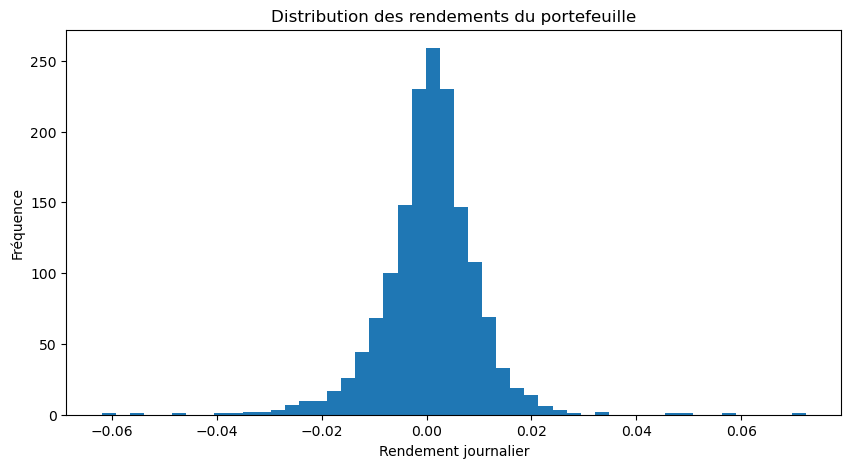

In [15]:
plt.figure(figsize=(10, 5))
plt.hist(port_returns, bins=50)
plt.title("Distribution des rendements du portefeuille")
plt.xlabel("Rendement journalier")
plt.ylabel("Fréquence")
plt.savefig("../figures/returns_distribution.png", bbox_inches="tight")
plt.show()

## 4. Backtesting de la VaR

Un backtesting sur fenêtre glissante de 252 jours est réalisé afin de comparer :
- la VaR historique
- la VaR paramétrique

Le principe consiste à estimer la VaR à partir des données passées, puis à comparer cette estimation à la perte réellement observée le jour suivant.

Une exception est observée lorsque la perte réalisée dépasse la VaR estimée.

In [10]:
bt_hist = rolling_var_backtest(port_returns, window=252, alpha=0.95, method="historical")
bt_para = rolling_var_backtest(port_returns, window=252, alpha=0.95, method="parametric")

print("Taux d'exceptions - VaR historique :", round(exception_rate(bt_hist), 4))
print("Taux d'exceptions - VaR paramétrique :", round(exception_rate(bt_para), 4))

Taux d'exceptions - VaR historique : 0.0563
Taux d'exceptions - VaR paramétrique : 0.0555


In [11]:
bt_hist.head()

,realized_return,VaR,exception
2021-01-04,0.001824,0.020398,False
2021-01-05,0.004293,0.020398,False
2021-01-06,-0.011509,0.020398,False
2021-01-07,0.008414,0.020398,False
2021-01-08,-0.009010,0.020398,False


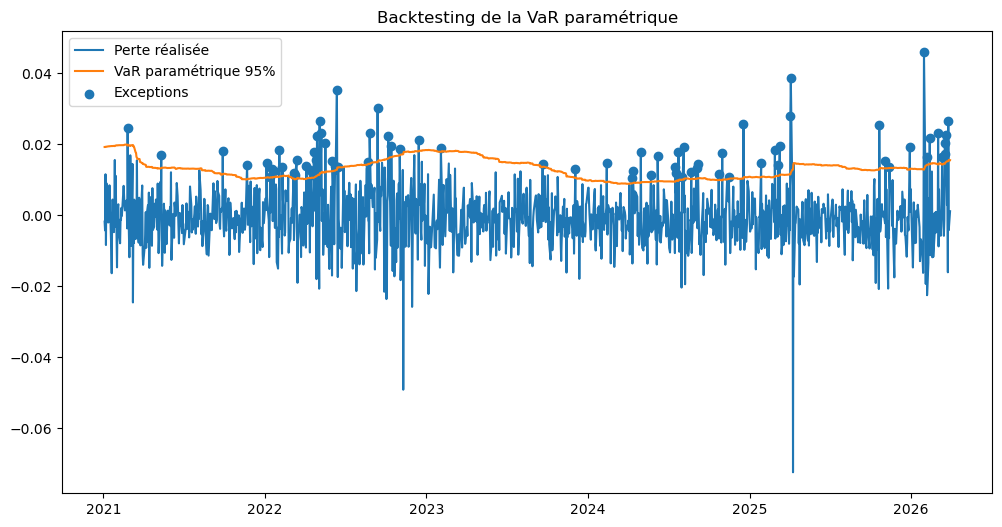

In [12]:
plt.figure(figsize=(12, 6))
plt.plot(bt_para.index, -bt_para["realized_return"], label="Perte réalisée")
plt.plot(bt_para.index, bt_para["VaR"], label="VaR paramétrique 95%")
plt.scatter(
    bt_para.index[bt_para["exception"]],
    (-bt_para["realized_return"])[bt_para["exception"]],
    label="Exceptions"
)
plt.title("Backtesting de la VaR paramétrique")
plt.legend()
plt.savefig("../figures/backtest_historical_var.png", bbox_inches="tight")
plt.show()

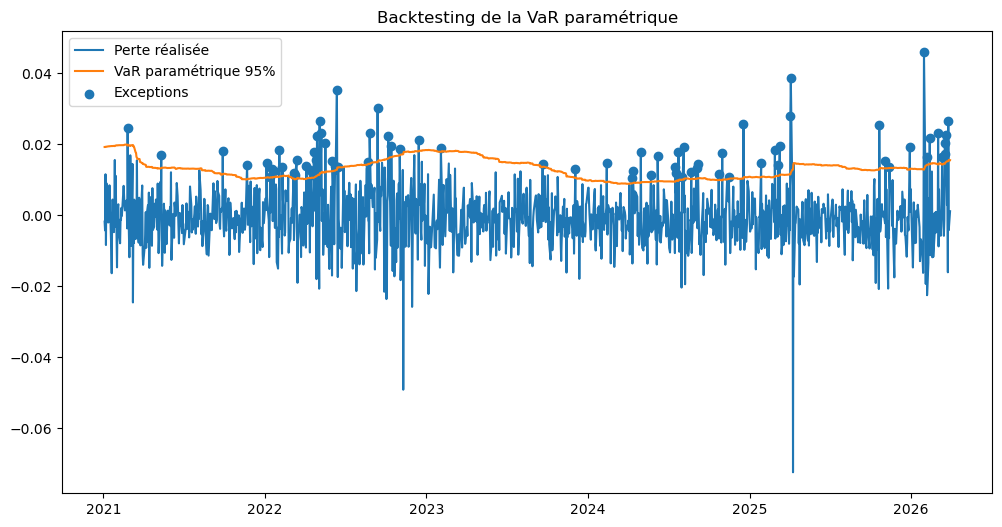

In [13]:
plt.figure(figsize=(12, 6))
plt.plot(bt_para.index, -bt_para["realized_return"], label="Perte réalisée")
plt.plot(bt_para.index, bt_para["VaR"], label="VaR paramétrique 95%")
plt.scatter(
    bt_para.index[bt_para["exception"]],
    (-bt_para["realized_return"])[bt_para["exception"]],
    label="Exceptions"
)
plt.title("Backtesting de la VaR paramétrique")
plt.legend()
plt.savefig("../figures/backtest_parametric_var.png", bbox_inches="tight")
plt.show()

### Interprétation du backtesting

Le taux d’exceptions observé peut être comparé au taux théorique attendu de 5 % pour une VaR à 95 %.

Un taux trop élevé peut signaler une sous-estimation du risque.  
Un taux trop faible peut au contraire suggérer une mesure trop conservatrice.

Ce backtesting simple permet d’évaluer la cohérence globale des modèles, tout en gardant à l’esprit certaines limites :
- dépendance à la période d’observation
- hypothèse de normalité pour la VaR paramétrique
- difficulté à capturer certains régimes de marché extrêmes

## 5. Conclusion

Ce projet permet de comparer plusieurs approches de mesure du risque de marché sur un portefeuille simple.

Les principaux enseignements sont :
- la VaR historique et la VaR paramétrique fournissent des estimations proches sur cet échantillon
- l’Expected Shortfall apporte une lecture plus informative du risque extrême
- le backtesting constitue un outil essentiel pour évaluer la qualité d’une mesure de risque

Le projet peut être prolongé par :
- une VaR Monte Carlo
- des stress tests
- un test de Kupiec
- une analyse sur d’autres portefeuilles ou d’autres horizons